In [1]:
import main_program as mp
import sys
import os
internal_WSM_dir = os.getcwd()
internal_PDC_dir = os.path.abspath(os.path.join(internal_WSM_dir, '..'))
root_dir = os.path.abspath(os.path.join(internal_PDC_dir, '..'))
internal_CP_dir = os.path.abspath(os.path.join(root_dir, '6_Common_Paramaters'))
sys.path.append(internal_CP_dir)
import Common_Params as CP
import matplotlib.pyplot as plt
import pickle

In [2]:
def plot(store_times, store_accelerations, store_velocities, store_seperations, store_detected_times, store_start_reaction_times, Dr, Vp):
    fig, axes = plt.subplots(1, 3, figsize = (90, 25 * 1))                              # figsize = (width, height)
    font = 50
    border_thickness = 8.0
    
    for i in range(3):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)  # Set border (spine) thickness

    axes[0].plot(store_times[0], store_seperations[0], label = f'min : {round(min(store_seperations[0]), 2)}, saturation : {round(store_seperations[0][-1], 2)}', color = 'blue', linewidth = 4)
    axes[0].plot(store_times[0], [CP.Dd + CP.Td * Vp for _ in range(len(store_seperations[0]))], label = f'Desired final seperation : {round(CP.Dd + CP.Td * Vp, 2)}', color = 'green', linewidth = 4)
    axes[0].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    axes[0].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
    axes[0].grid(True, linewidth = 4.0)
    axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[0].set_ylabel('Seperation [m]', fontsize = font, fontweight = 'bold')
    axes[0].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[0].legend(fontsize = font)

    axes[1].plot(store_times[0], store_velocities[0], label = f'saturation : {round(store_velocities[0][-1], 2)}, max : {round(max(store_velocities[0]), 2)}', color = 'blue', linewidth = 4)
    axes[1].plot(store_times[0], [Vp * 18 / 5 for _ in range(len(store_velocities[0]))], label = f'Desired final velocity : {round(Vp * 18 / 5, 2)} km/hr', color = 'green', linewidth = 4)
    axes[1].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    axes[1].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
    axes[1].grid(True, linewidth = 4.0)
    axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    axes[1].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[1].legend(fontsize = font)

    axes[2].plot(store_times[0], store_accelerations[0], label = f'min : {round(min(store_accelerations[0]), 2)}, max : {round(max(store_accelerations[0]), 2)}', color = 'blue', linewidth = 4)
    axes[2].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    axes[2].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
    axes[2].grid(True, linewidth = 4.0)
    axes[2].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[2].set_ylabel('Acceleration [m/s^2]', fontsize = font, fontweight = 'bold')
    axes[2].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[2].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[2].legend(fontsize = font)

    plt.show()

In [3]:
store_separations, store_accelerations, store_velocities, store_times, store_detected_times, store_start_reaction_times = mp.main(0.3)

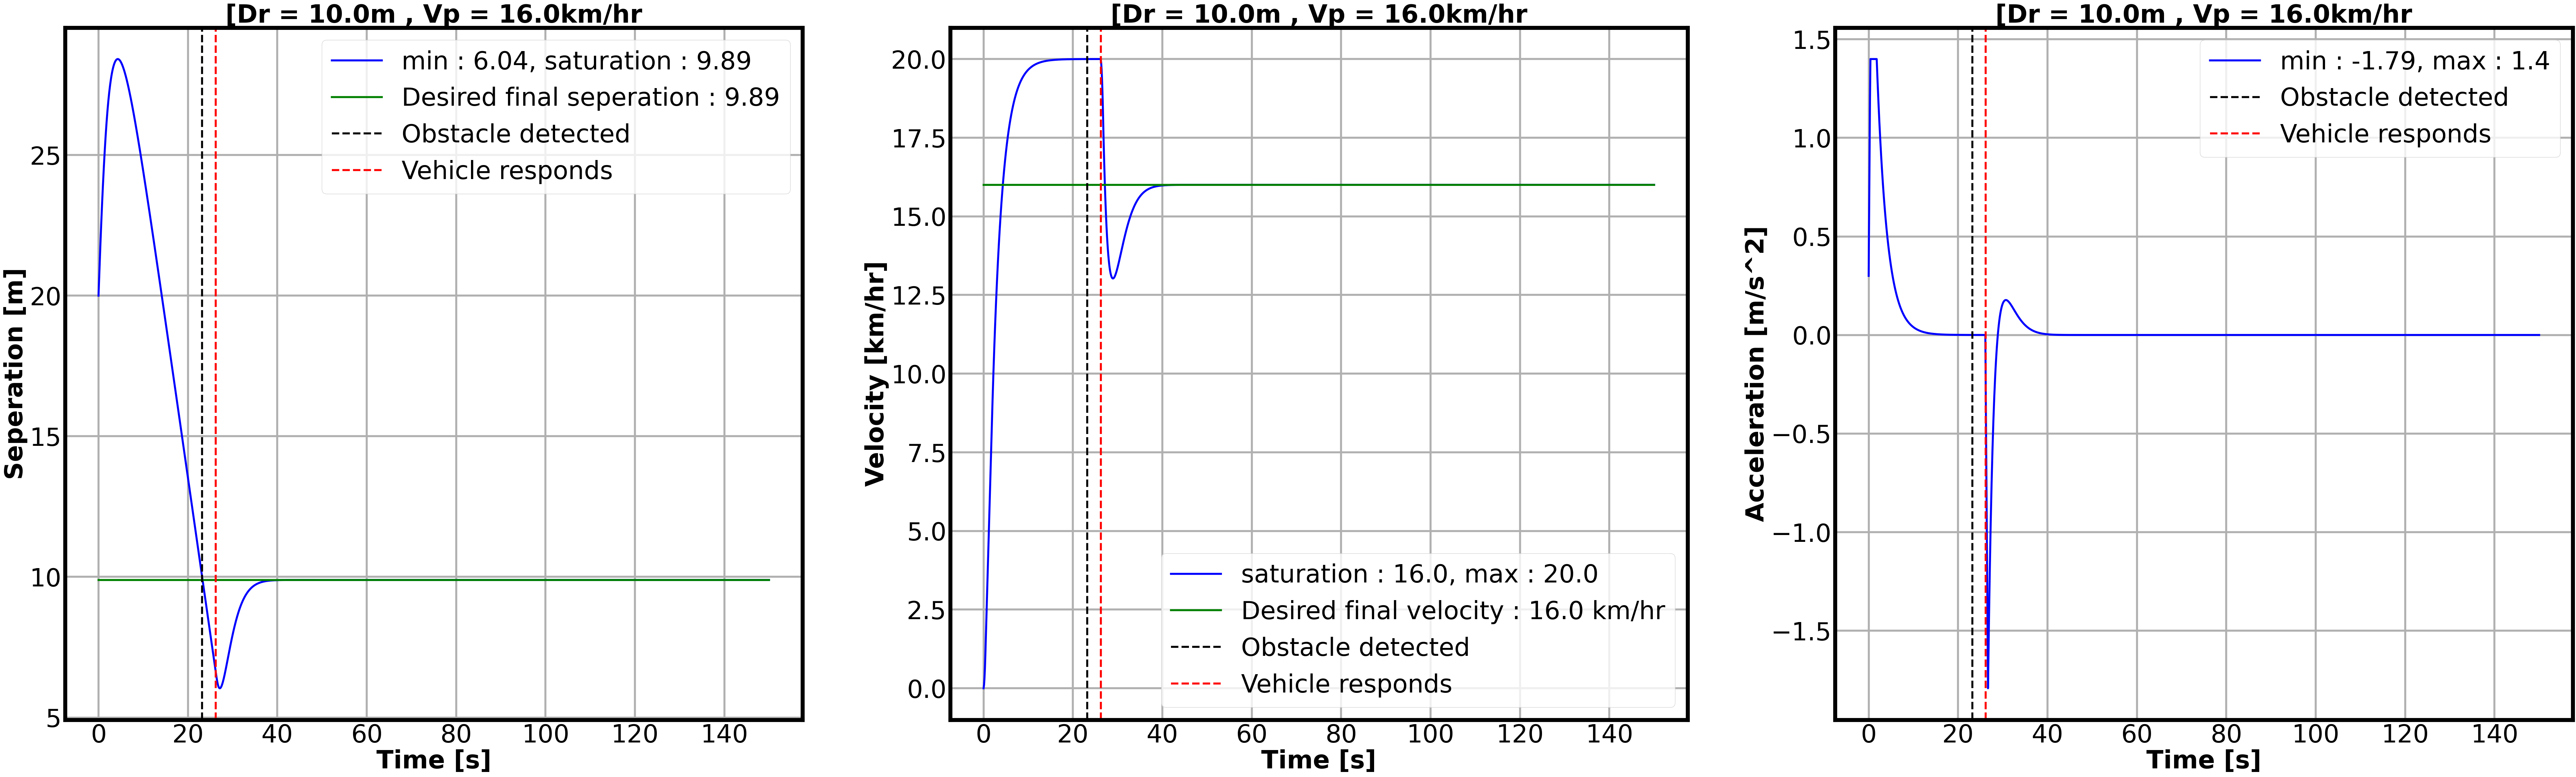

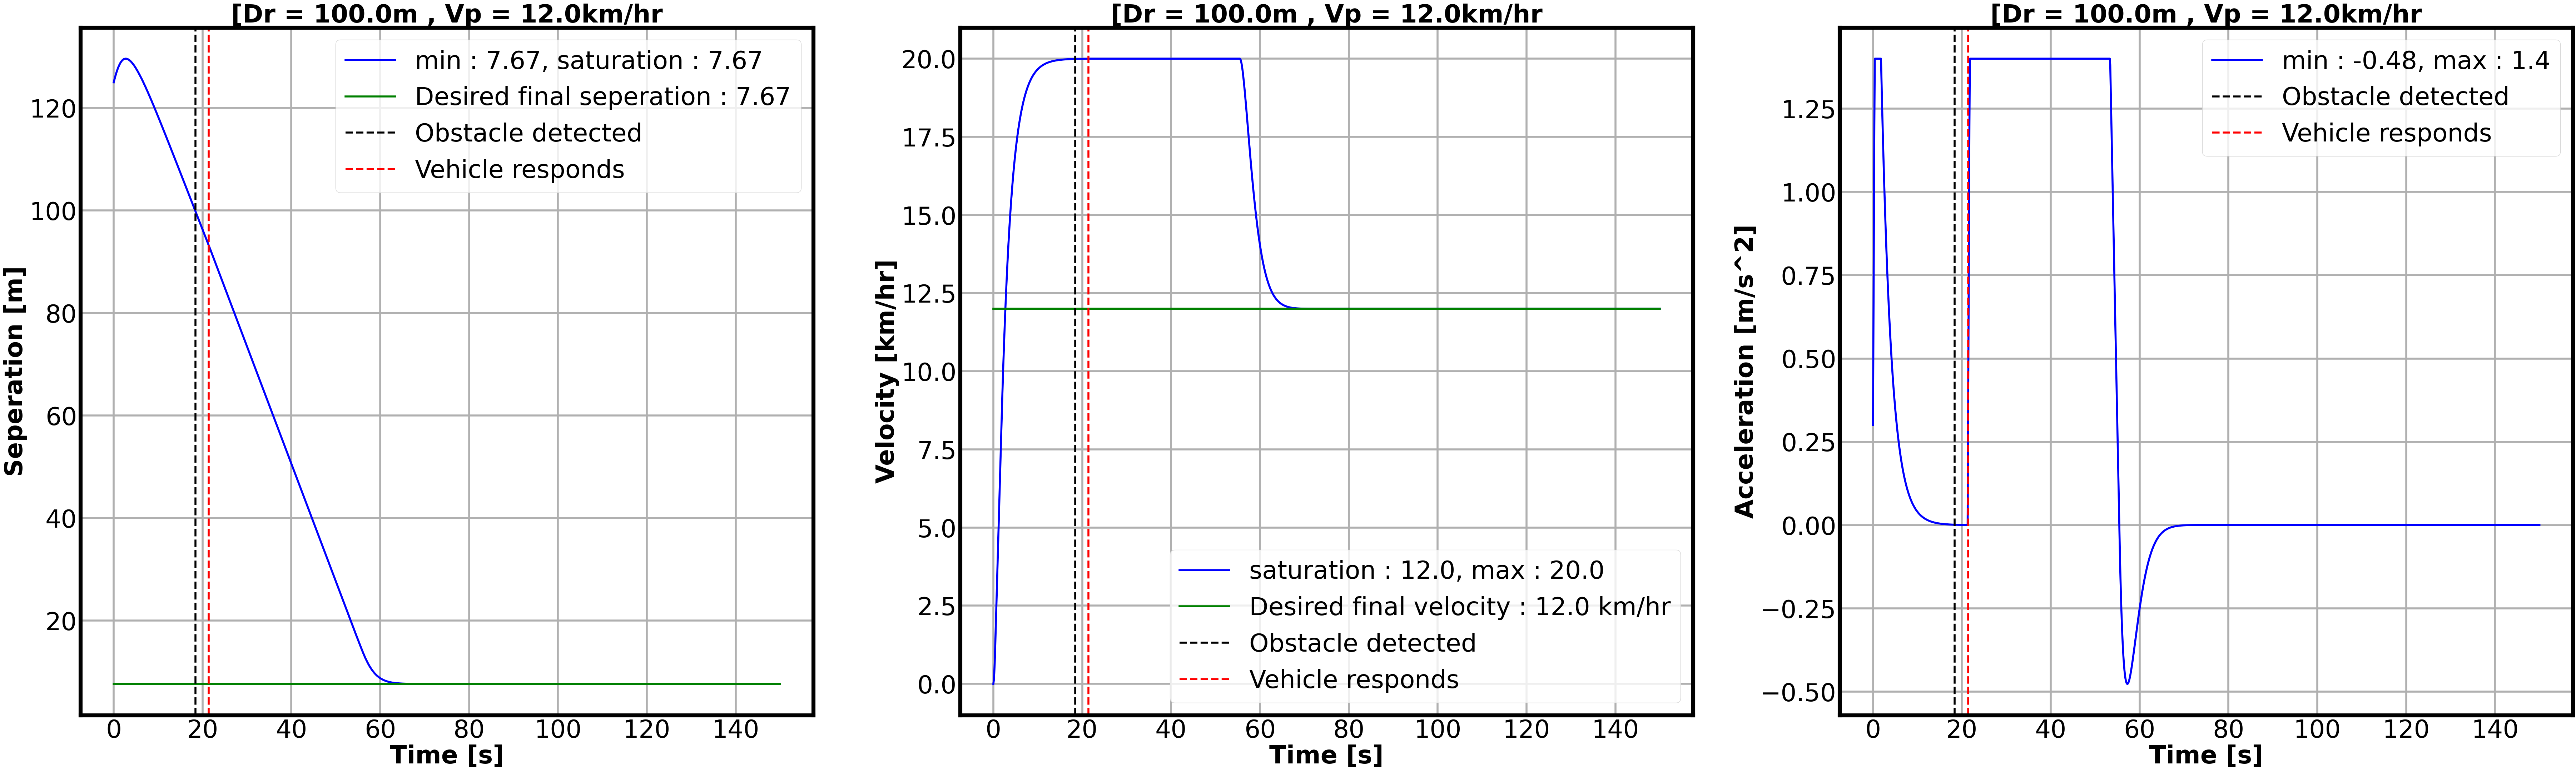

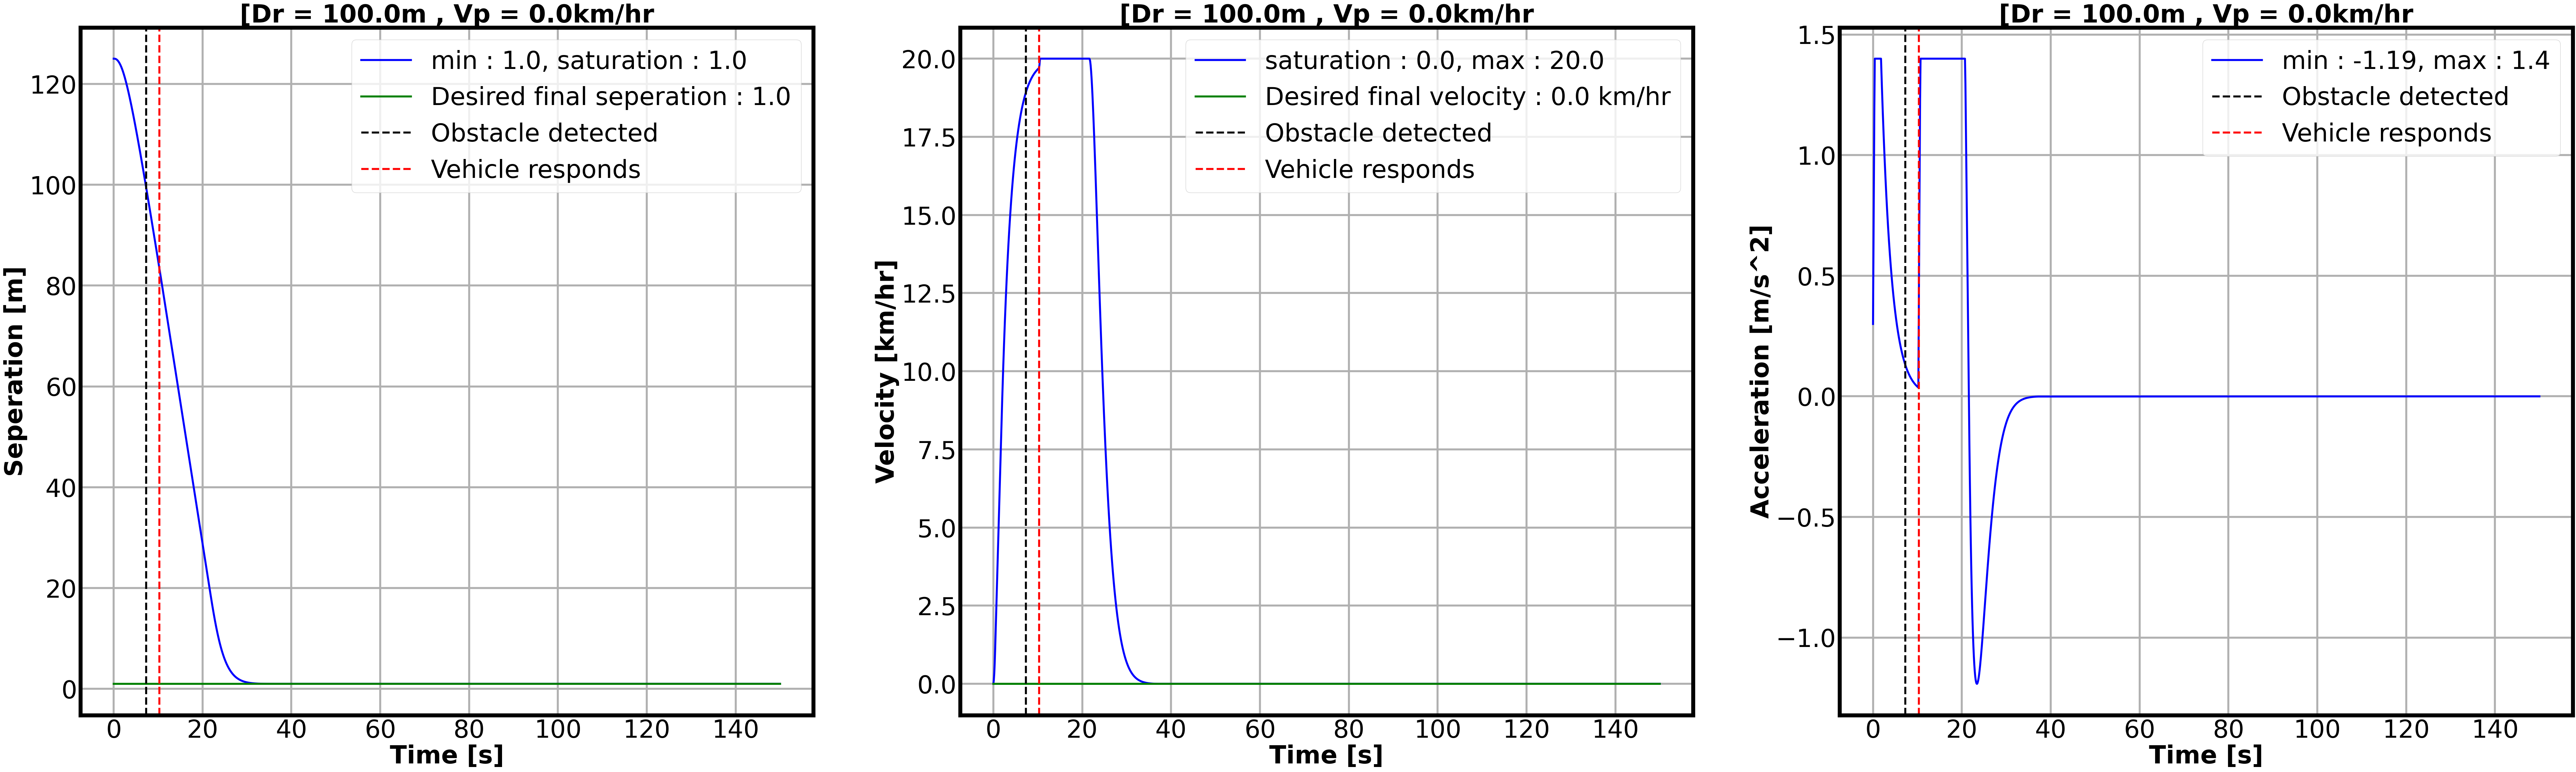

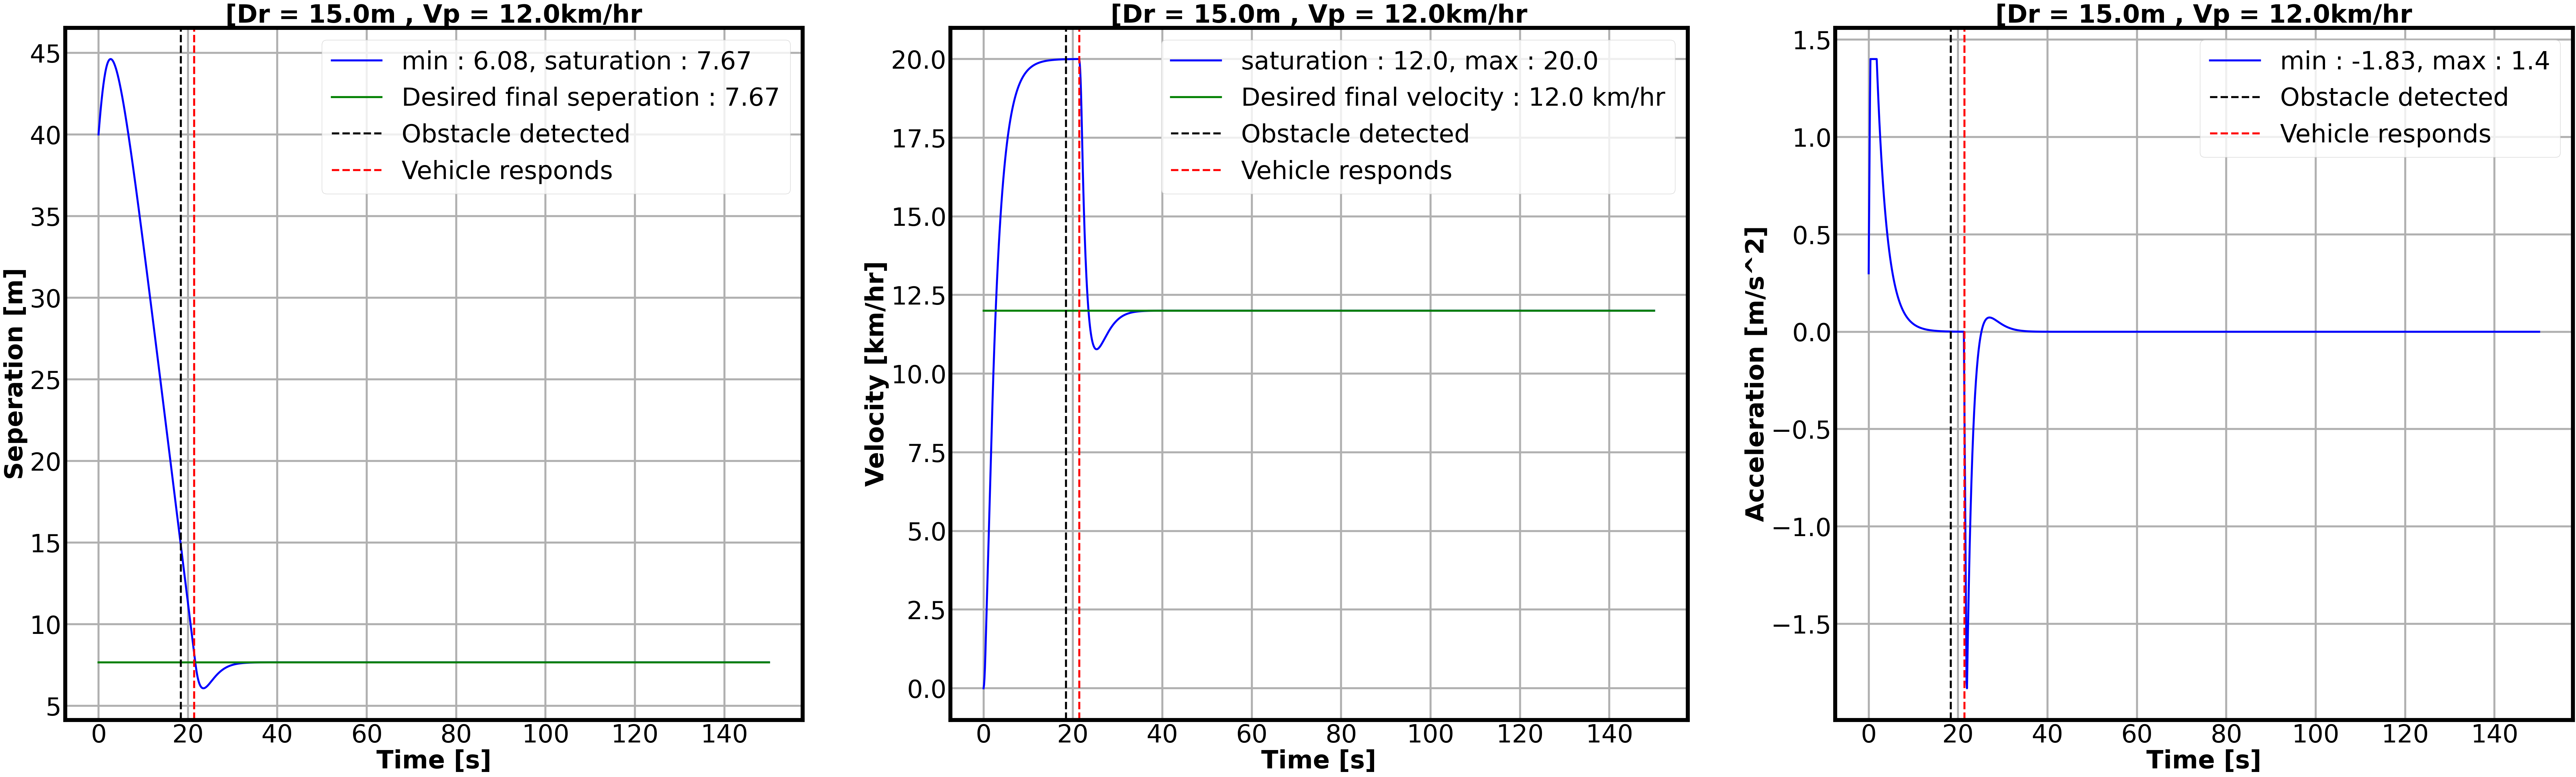

In [4]:
for i in range(len(store_times)):
    plot([store_times[i]], [store_accelerations[i]], [store_velocities[i]], [store_separations[i]], store_detected_times[i], store_start_reaction_times[i], CP.Drs[i], CP.Vps[i])

In [5]:
folder_path = os.path.join(internal_WSM_dir, 'store_results_data')
times_file_path = os.path.join(folder_path, 'times.pkl')
separations_file_path = os.path.join(folder_path, 'separations.pkl')
velocities_file_path = os.path.join(folder_path, 'velocities.pkl')
accelerations_file_path = os.path.join(folder_path, 'accelerations.pkl')
detected_times_file_path = os.path.join(folder_path, 'detected_times.pkl')
start_reaction_times_file_path = os.path.join(folder_path, 'start_reaction_times.pkl')

with open(times_file_path, 'wb') as f:
    pickle.dump(store_times, f)
    
with open(separations_file_path, 'wb') as f:
    pickle.dump(store_separations, f)

with open(velocities_file_path, 'wb') as f:
    pickle.dump(store_velocities, f)

with open(accelerations_file_path, 'wb') as f:
    pickle.dump(store_accelerations, f)

with open(detected_times_file_path, 'wb') as f:
    pickle.dump(store_detected_times, f)
    
with open(start_reaction_times_file_path, 'wb') as f:
    pickle.dump(store_start_reaction_times, f)

print(f"The required data has been saved at : {folder_path}")

The required data has been saved at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\4_PD_Controllers\1_Without_System_model\store_results_data
